In [1903]:
from datetime import datetime, timezone
from influxdb_client import InfluxDBClient, Point, WritePrecision
from influxdb_client.client.write_api import SYNCHRONOUS
from random import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Replace these with your InfluxDB token, organization, and bucket
org = "ur3e"
bucket = "ur3e"
token = "-BZITnY_s_YijW3jrGyzuOgiQxxMtXEU9U_yxpBLYlUiPZw0kKvethzTBR2A4NqZuVVw-2bKQ70rDUuPgNCQJQ=="

# Initialize the client
client = InfluxDBClient(url="http://localhost:8086", token=token, org=org)
write_api = client.write_api(write_options=SYNCHRONOUS)   
query_api = client.query_api()

In [1904]:
time_start = "-5m"
time_stop = "now()"
window = "1s"

query_sensor_data = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "sensor_data")
  |> filter(fn: (r) => r["_field"] =~ /q_actual_joint_0/)
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
'''

query_model_data = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "dt_model_Data")
  |> filter(fn: (r) => r["_field"] =~ /q_actual_joint_0/)
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
'''

df_sensor_data = query_api.query_data_frame(query_sensor_data)
df_model_data = query_api.query_data_frame(query_model_data)

In [1905]:
print(df_sensor_data.head())

    result  table                            _time  \
0  _result      0 2026-04-07 08:12:38.726083+00:00   
1  _result      0 2026-04-07 08:12:38.776401+00:00   
2  _result      0 2026-04-07 08:12:38.827201+00:00   
3  _result      0 2026-04-07 08:12:38.875152+00:00   
4  _result      0 2026-04-07 08:12:38.923814+00:00   

                            _start                            _stop  \
0 2026-04-07 08:08:46.551043+00:00 2026-04-07 08:13:46.551043+00:00   
1 2026-04-07 08:08:46.551043+00:00 2026-04-07 08:13:46.551043+00:00   
2 2026-04-07 08:08:46.551043+00:00 2026-04-07 08:13:46.551043+00:00   
3 2026-04-07 08:08:46.551043+00:00 2026-04-07 08:13:46.551043+00:00   
4 2026-04-07 08:08:46.551043+00:00 2026-04-07 08:13:46.551043+00:00   

  _measurement     source  q_actual_joint_0  
0  sensor_data  pt_mockup      7.736163e-09  
1  sensor_data  pt_mockup     -8.047148e-08  
2  sensor_data  pt_mockup     -1.647498e-07  
3  sensor_data  pt_mockup     -1.508293e-07  
4  sensor_data  pt

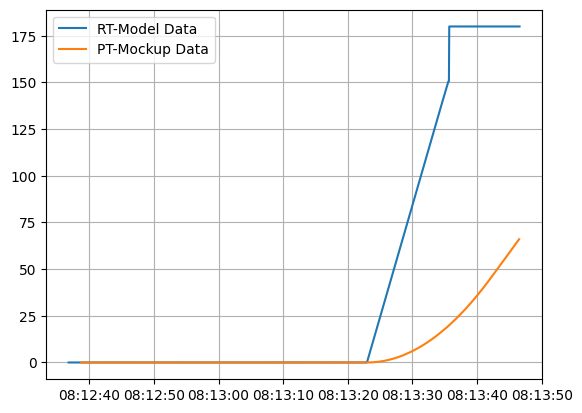

In [1906]:
sensor_data_np = df_sensor_data.to_numpy()
model_data_np = df_model_data.to_numpy()

joint_0_q_sensor = sensor_data_np[:, -1]
timestamp_sensor = sensor_data_np[:, 2]

joint_0_q_model = model_data_np[:, -1]
timestamp_model = model_data_np[:, 2]

# Convert to degrees
def rad2deg(x):
    return 180*x/np.pi
joint_0_q_sensor = rad2deg(joint_0_q_sensor)
joint_0_q_model = rad2deg(joint_0_q_model)

plt.plot(timestamp_model, joint_0_q_model, '-', label="RT-Model Data")
plt.plot(timestamp_sensor, joint_0_q_sensor, '-', label="PT-Mockup Data")
plt.legend()
plt.grid()


46.87533490280943

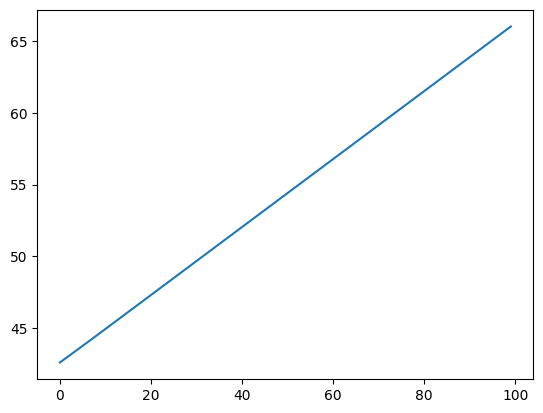

In [1907]:
diff = joint_0_q_sensor

plt.plot(diff[-100:], '-', label="RT-Model Data")
np.var(diff[-100:]).item()